<a href="https://colab.research.google.com/github/cary0304/-./blob/main/%E7%AC%AC%E4%B8%83%E7%B5%84_Python%E6%9C%9F%E6%9C%AB%E5%A0%B1%E5%91%8A_%E8%85%A6%E7%98%A4%E6%AA%A2%E6%B8%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#連接雲端
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install keras  # 使用pip安裝Keras函式庫

In [ ]:
import numpy as np  # 匯入numpy套件，簡稱np
import pandas as pd  # 匯入pandas函式庫，簡稱pd
import os  # 匯入模組

In [ ]:
import matplotlib.pyplot as plt  # 匯入matplotlib.pyplot套件，簡稱plt
import cv2  # 匯入cv2

# 定義資料夾路徑和分類標籤
DATADIR = "/content/drive/MyDrive/Python期末檔案/training"  # 'Python期末檔案/testing'
CATEGORIES = ["glioma_tumor","meningioma_tumor","no_tumor","pituitary_tumor"]

# 對於每個分類標籤構建路徑並讀取該路徑下的第一張圖片。
for category in CATEGORIES:
    path = os.path.join(DATADIR,category)
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path,img))  # 使用cv2讀取圖片
        plt.imshow(img_array)  # 顯示圖片
        plt.show()
        plt.axis("off")  # 不用座標尺
        break
    break

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Python期末檔案/training/glioma_tumor'

(-0.5, 149.5, 149.5, -0.5)

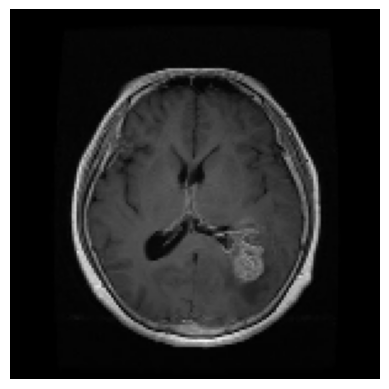

In [ ]:
IMG_SIZE = 150
new_array = cv2.resize(img_array,(IMG_SIZE,IMG_SIZE))  # 調整圖像大小為150像素
plt.imshow(new_array,cmap = "gray")  # 設定顏色圖譜為灰色，並顯示
plt.axis("off")  # 不用座標尺

In [ ]:
training_data = []  # 初始化一個名為training_data的空串列，用於儲存訓練資料

def create_training_data():  # 自訂函數create_training_data，用於生成訓練資料
    for category in CATEGORIES:  # 遍歷CATEGORIES中的每個類別
        path = os.path.join(DATADIR,category)  # 拼接出當前類別的資料夾路徑
        class_num = CATEGORIES.index(category)  # 裡用函式index獲取當前類別的索引號
        for img in os.listdir(path):  # 遍歷當前類別資料夾中的每個圖像檔案
            try:  # 利用try-except處理例外
                img_array = cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)  # 讀取圖像檔案，並轉換為灰度圖像
                new_array = cv2.resize(img_array,(IMG_SIZE,IMG_SIZE))  # 將圖像縮放至 IMG_SIZE * IMG_SIZE 尺寸
                training_data.append([new_array,class_num])  # 在串列末尾附加新元素
            # 利用try-except處理例外
            except Exception as e:
                pass
create_training_data()  # 呼叫create_training_data函數，生成訓練資料

In [ ]:
X = []  # 初始化空列表X，儲存特徵資料
y = []  # 初始化空列表y，儲存標籤資料

# 將每個特徵資料添加到X列表、標籤資料添加到y列表
for features,label in training_data:
    X.append(features)
    y.append(label)

X = np.array(X).reshape(-1,IMG_SIZE,IMG_SIZE)  # 將資料轉換為陣列np.array，改變矩陣形狀
print(X.shape)

X = X/255.0  # 將資料標準化於0-1之間
X = X.reshape(-1,150,150,1) # 重新調整 X 陣列的形狀

(2870, 150, 150)


In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# 將標籤轉換為one-hot, 向量總類別數num_classes
y = to_categorical(y, num_classes = 4)

In [ ]:
# 引入 train_test_split 函數分割訓練和驗證資料
from sklearn.model_selection import train_test_split

# 分割訓練和驗證資料集, 測試資料test_size為20%，隨機數random_state
X_train, X_val, Y_train, Y_val = train_test_split(X, y, test_size = 0.2, random_state=42)

# 輸出訓練資料形狀
print("x_train shape",X_train.shape)
print("x_test shape",X_val.shape)
print("y_train shape",Y_train.shape)
print("y_test shape",Y_val.shape)

x_train shape (2296, 150, 150, 1)
x_test shape (574, 150, 150, 1)
y_train shape (2296, 4)
y_test shape (574, 4)


In [ ]:
from sklearn.metrics import confusion_matrix  # 匯入混淆矩陣函數
import itertools  # 匯入迭代器

from tensorflow.keras.utils import to_categorical  # 匯入one-hot編碼函數
from keras.models import Sequential  # 匯入序貫模型

# 從keras.Layers匯入層數、捨棄層、平坦層、二維卷積層、二維最大池化層及優化器
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import RMSprop,Adam
from keras.preprocessing.image import ImageDataGenerator  # 匯入影像資料生成器
from keras.callbacks import ReduceLROnPlateau  # 匯入降低學習率回調函數

In [ ]:
from tensorflow.keras.optimizers import Adam  # 導入Adam優化器

model = Sequential()  # 定義序列式模型

# 定義第一個卷積層
model.add(Conv2D(filters=64, kernel_size=(5,5), padding='Same',
                 activation='relu', input_shape=(150,150,1)))
    # filters: 輸出通道數 (特徵數量)
    # kernel_size: 卷積核大小
    # padding: 邊緣填充方式 (Same: 保持輸入輸出尺寸相同)
    # activation: 激活函數: relu
    # input_shape: 150x150 灰度圖像

# 定義最大池化層，設定池化窗口大小
model.add(MaxPool2D(pool_size=(2,2)))

# 定義Dropout層，隨機斷開25%的神經元
model.add(Dropout(0.25))


# 逐層堆疊卷積、池化、Dropout層
model.add(Conv2D(filters=128, kernel_size=(3,3), padding='Same',
                 activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters=128, kernel_size=(3,3), padding='Same',
                 activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(filters=128, kernel_size=(2,2), padding='Same',
                 activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(filters=256, kernel_size=(2,2), padding='Same',
                 activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.3))

# 平坦層，將特徵圖轉換為一维向量
model.add(Flatten())

# 建立全連接層(Fully Connected Layer)隱藏層，設定神經元數目4~1024個，使用rulu和softmax激勵函數
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))  # 隨機斷開50%的神經元
model.add(Dense(4, activation='softmax'))

# Adam優化器參數lr: 學習率、beta_1、beta_2
optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

epochs = 5  # 單次迭代數目
batch_size = 40   # 批量大小

# 定義圖像數據生成器
datagen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=0,
    zoom_range=0,
    width_shift_range=0,
    height_shift_range=0,
    horizontal_flip=True,
    vertical_flip=False
)


In [ ]:
datagen.fit(X_train)  # 進行批次訓練
history = model.fit_generator(datagen.flow(X_train,Y_train, batch_size=batch_size),
                              epochs = epochs, validation_data = (X_val,Y_val),
                              steps_per_epoch = X_train.shape[0] // batch_size)  # 加入平坦層Flatten

Epoch 1/5


<ipython-input-15-ddafaed47ed3>:2: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(datagen.flow(X_train,Y_train, batch_size=batch_size),


57/57 [==============================] - 314s 5s/step - loss: 1.2732 - accuracy: 0.4131 - val_loss: 1.1241 - val_accuracy: 0.5105
Epoch 2/5
57/57 [==============================] - 319s 6s/step - loss: 0.9318 - accuracy: 0.6113 - val_loss: 0.8335 - val_accuracy: 0.6603
Epoch 3/5
57/57 [==============================] - 332s 6s/step - loss: 0.8329 - accuracy: 0.6543 - val_loss: 0.8243 - val_accuracy: 0.6429
Epoch 4/5
57/57 [==============================] - 317s 6s/step - loss: 0.7076 - accuracy: 0.7004 - val_loss: 0.8888 - val_accuracy: 0.6167
Epoch 5/5
57/57 [==============================] - 305s 5s/step - loss: 0.6376 - accuracy: 0.7252 - val_loss: 0.7790 - val_accuracy: 0.6585


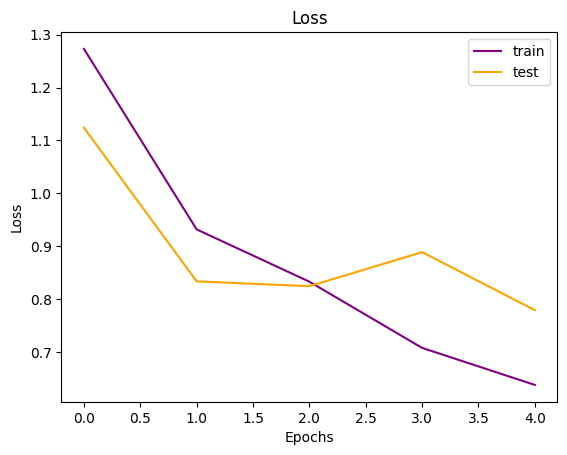

In [ ]:
# 繪製訓練損失曲線
plt.plot(history.history["loss"],c = "purple")

# 繪製驗證損失曲線
plt.plot(history.history["val_loss"],c = "orange")

# 設定圖表標題和軸標籤
plt.title("Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")

# 設定圖例
plt.legend(["train", "test"])

# 顯示圖表
plt.show()

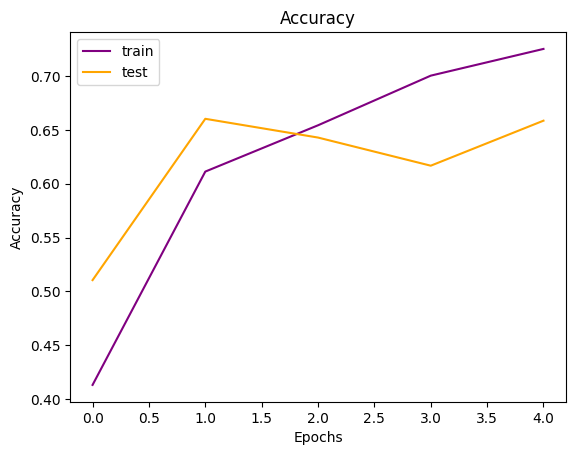

In [ ]:
# 繪製訓練準確率曲線
plt.plot(history.history["accuracy"],c = "purple")

# 繪製驗證準確率曲線
plt.plot(history.history["val_accuracy"],c = "orange")

# 設定圖表標題和軸標籤
plt.title("Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")

# 設定圖例
plt.legend(["train", "test"])

# 顯示圖表
plt.show()

#測試模型

In [ ]:
# 定義資料夾路徑和分類標籤
TESTDIR = '/content/drive/MyDrive/Python期末檔案/testing'  # 'Python期末檔案/testing'
CATEGORIES = ["glioma_tumor","meningioma_tumor","no_tumor","pituitary_tumor"]

In [ ]:
test_data = []  # 創建測試數據列表


"""
遍歷每個類別的測試圖像目錄，將圖轉換成灰度格式並縮放到指定大小後，
將對應的類別編號一起添加到測試數據列表中
"""
def create_test_data():
    for category in CATEGORIES:
        path = os.path.join(TESTDIR, category)
        class_num = CATEGORIES.index(category)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                test_data.append([new_array, class_num])
            except Exception as e:
                pass

# 創建測試數據
create_test_data()

In [ ]:
X_test = []
y_test = []

# 將每個特徵資料添加到X列表、標籤資料添加到y列表
for features, label in test_data:
    X_test.append(features)
    y_test.append(label)

# 轉換為numpy數組並調整形狀
X_test = np.array(X_test).reshape(-1, IMG_SIZE, IMG_SIZE)
print(X_test.shape)

# 標準化數據
X_test = X_test / 255.0
X_test = X_test.reshape(-1, 150, 150, 1)


(394, 150, 150)


In [ ]:
# 將測試數據標籤轉換為one-hot
y_test = to_categorical(y_test, num_classes=4)

In [ ]:
# 評估模型在測試數據集上的性能
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# 印出測試損失和測試準確率
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

13/13 [==============================] - 13s 986ms/step - loss: 1.7557 - accuracy: 0.3909
Test Loss: 1.7557408809661865
Test Accuracy: 0.39086294174194336


###進一步生成混淆矩陣和分類報告來詳細評估模型

**分類報告**：列出了每個類別的精確度、召回率和F1分數。
*   精確度 (Precision): 對某一類別的預測中正確預測的比例
*   召回率 (Recall): 該類別實際樣本中被正確預測的比例
*   F1分數 (F1-Score): 精確度和召回率的調和平均數。
*   支持數 (Support): 每個類別中的實際樣本數


**混淆矩陣**：混淆矩陣顯示了真實標籤和模型預測之間的對比。每行表示實際類別，每列表示預測類別。


13/13 [==============================] - 12s 901ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.43      0.18      0.25       100
meningioma_tumor       0.56      0.16      0.24       115
        no_tumor       0.38      0.63      0.47       105
 pituitary_tumor       0.36      0.70      0.47        74

        accuracy                           0.39       394
       macro avg       0.43      0.42      0.36       394
    weighted avg       0.44      0.39      0.35       394



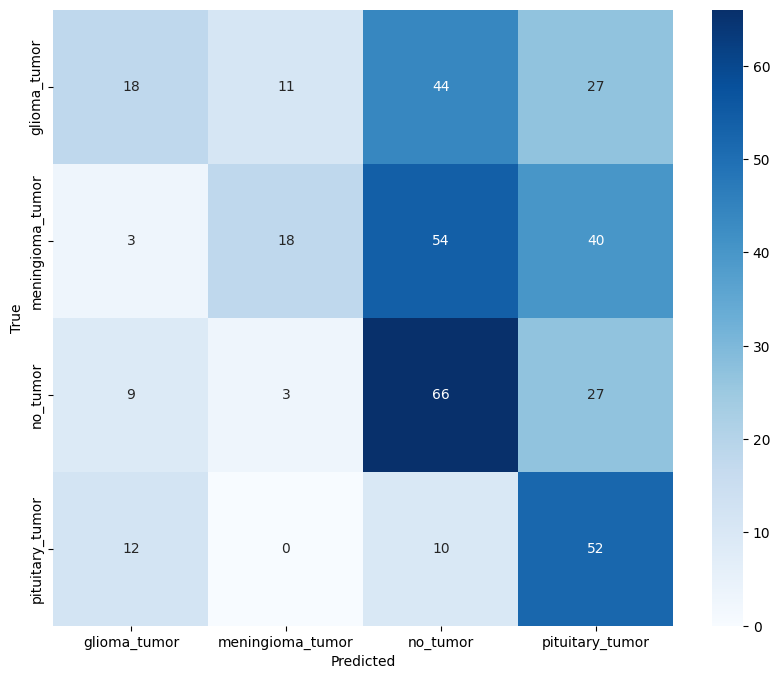

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 使用模型進行預測，得到標籤y_pred
y_pred = model.predict(X_test)

# 將預測標籤y_pred轉換為整數形式，表示每個樣本預測的類別
y_pred_classes = np.argmax(y_pred, axis=1)

# 將真實標籤 y_test 轉換為整數形式，表示每個樣本的真實類別
y_true = np.argmax(y_test, axis=1)

# 印出分類報告，顯示模型在每個類別上的準確率、召回率、F1分數和支持數
print(classification_report(y_true, y_pred_classes, target_names=CATEGORIES))

# 畫出混淆矩陣
confusion_mtx = confusion_matrix(y_true, y_pred_classes)  # 生成混淆矩陣
plt.figure(figsize=(10, 8))  # 創建一個大小為(10, 8)的圖表

# 使用seaborn的heatmap()函數繪製混淆矩陣。
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.xlabel('Predicted')
plt.ylabel('True')

# 顯示矩陣
plt.show()


##參考資料：
##code: https://www.kaggle.com/erkamk/brain-tumor-classification-with-cnn
## data: https://www.kaggle.com/sartajbhuvaji/brain-tumor-classification-mri